# 📉Customer Churn Prediction — Classification
A machine learning project to predict customer churn using classification models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries loaded ✅')

Libraries loaded ✅


## 1️⃣ Load Dataset — Telecom Customer Churn

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print(f'Dataset Shape: {df.shape}')
print(f'\nChurn Distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn Rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')
df.head()

Dataset Shape: (7043, 21)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2️⃣ Data Preprocessing

In [3]:
df_clean = df.copy()

# CustomerID drop karo
df_clean.drop('customerID', axis=1, inplace=True)

# TotalCharges numeric mein convert karo
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# Target encode karo
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

# Binary cols encode karo
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col])

# Multi-category cols — One Hot Encode
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

print('Preprocessing done ✅')
print(f'Shape after encoding: {df_clean.shape}')
print(f'Missing values: {df_clean.isnull().sum().sum()}')
df_clean.head()

Preprocessing done ✅
Shape after encoding: (7043, 31)
Missing values: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


## 3️⃣ EDA — Churn Patterns

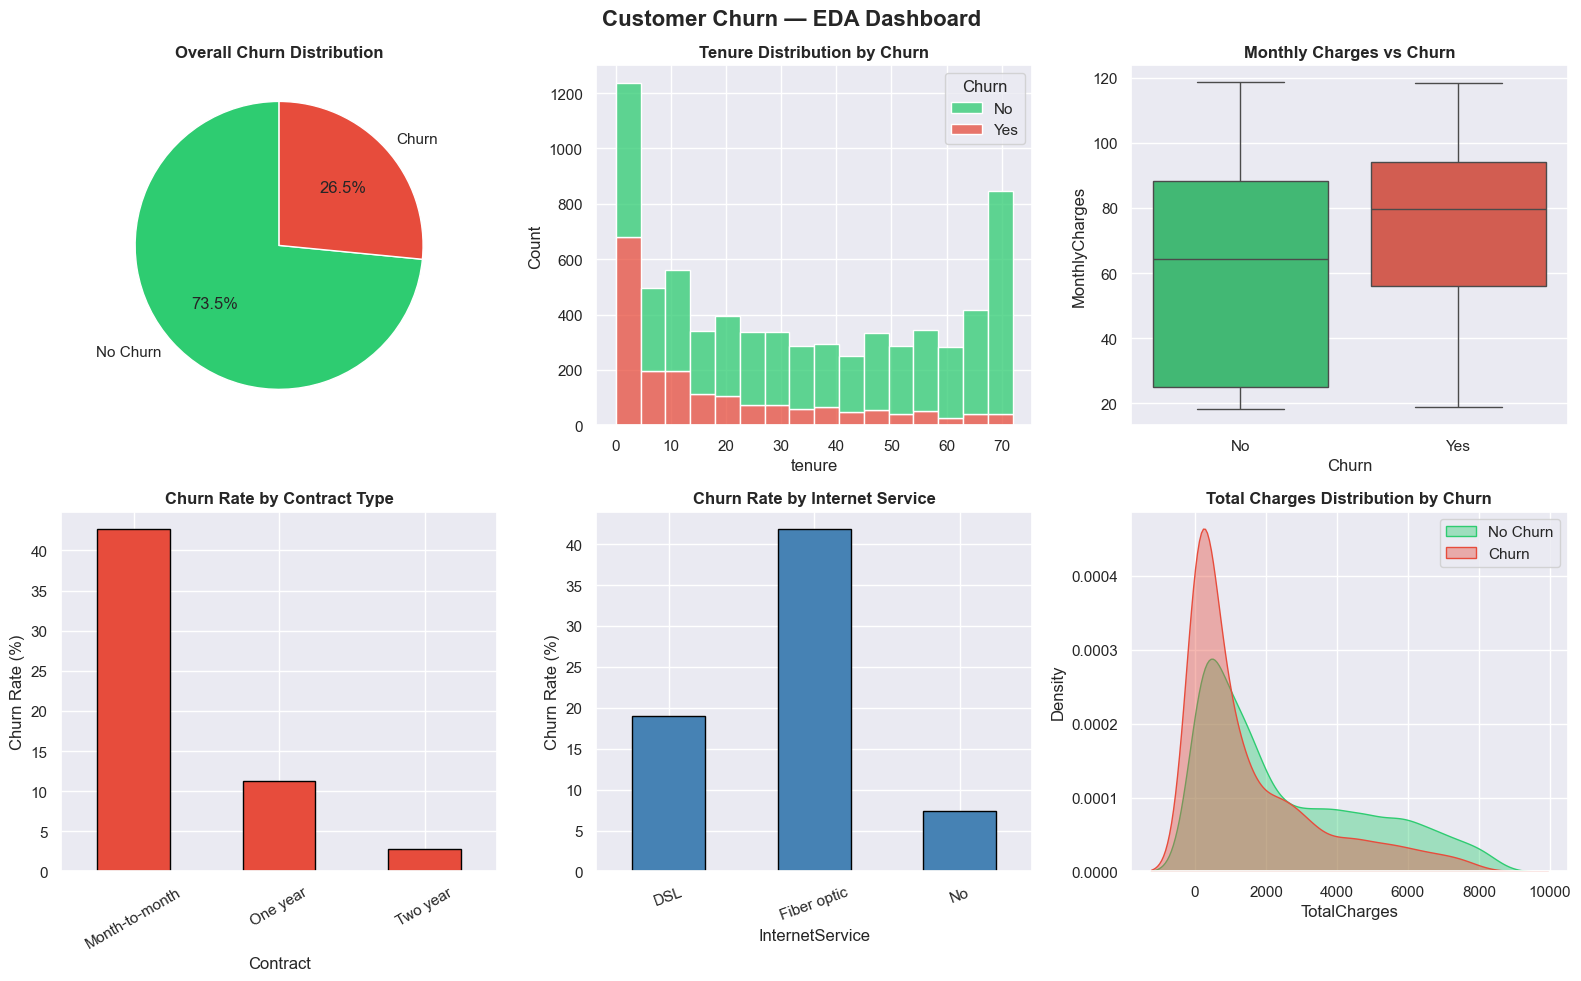

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0,0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
              colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0,0].set_title('Overall Churn Distribution', fontweight='bold')

# Tenure vs Churn
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', ax=axes[0,1],
             palette={'No':'#2ecc71','Yes':'#e74c3c'})
axes[0,1].set_title('Tenure Distribution by Churn', fontweight='bold')

# Monthly Charges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0,2],
            palette={'No':'#2ecc71','Yes':'#e74c3c'})
axes[0,2].set_title('Monthly Charges vs Churn', fontweight='bold')

# Contract vs Churn
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct['Yes'].plot(kind='bar', ax=axes[1,0], color='#e74c3c', edgecolor='black')
axes[1,0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].tick_params(axis='x', rotation=30)

# Internet Service vs Churn
ct2 = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
ct2['Yes'].plot(kind='bar', ax=axes[1,1], color='steelblue', edgecolor='black')
axes[1,1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].tick_params(axis='x', rotation=20)

# TotalCharges vs Churn
sns.kdeplot(data=df[df['Churn']=='No'], x=pd.to_numeric(df[df['Churn']=='No']['TotalCharges'], errors='coerce'),
            ax=axes[1,2], color='#2ecc71', label='No Churn', fill=True, alpha=0.4)
sns.kdeplot(data=df[df['Churn']=='Yes'], x=pd.to_numeric(df[df['Churn']=='Yes']['TotalCharges'], errors='coerce'),
            ax=axes[1,2], color='#e74c3c', label='Churn', fill=True, alpha=0.4)
axes[1,2].set_title('Total Charges Distribution by Churn', fontweight='bold')
axes[1,2].legend()

plt.suptitle('Customer Churn — EDA Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4️⃣ Feature Engineering

In [5]:
df_feat = df_clean.copy()

# New features
df_feat['ChargesPerMonth']     = df_feat['TotalCharges'] / (df_feat['tenure'] + 1)
df_feat['HighValueCustomer']   = (df_feat['MonthlyCharges'] > df_feat['MonthlyCharges'].median()).astype(int)
df_feat['LongTermCustomer']    = (df_feat['tenure'] > 24).astype(int)  # 2+ years
df_feat['ChargesVsTenureRatio'] = df_feat['MonthlyCharges'] / (df_feat['tenure'] + 1)

print('Feature Engineering done ✅')
print(f'Total features: {df_feat.shape[1] - 1}')

Feature Engineering done ✅
Total features: 34


## 5️⃣ Model Training — Multiple Classifiers

In [6]:
X = df_feat.drop('Churn', axis=1)
y = df_feat['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'Churn rate (train): {y_train.mean()*100:.1f}%')
plt.show()

Train: 5634 samples
Test:  1409 samples
Churn rate (train): 26.5%


In [7]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = []
trained_models = {}

for name, model in classifiers.items():
    if 'Forest' in name or 'Boosting' in name or 'Tree' in name:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    roc    = roc_auc_score(y_test, y_prob)
    
    results.append({'Model': name, 'Accuracy': round(acc,4), 'F1-Score': round(f1,4), 'ROC-AUC': round(roc,4)})
    trained_models[name] = (model, y_pred, y_prob)
    print(f'{name:25s} | Acc: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\n=== Model Comparison ===')
print(results_df.to_string(index=False))
plt.show()

Logistic Regression       | Acc: 0.8055 | F1: 0.5910 | ROC-AUC: 0.8472
Decision Tree             | Acc: 0.7786 | F1: 0.5655 | ROC-AUC: 0.8200
Random Forest             | Acc: 0.7871 | F1: 0.5427 | ROC-AUC: 0.8210
Gradient Boosting         | Acc: 0.8013 | F1: 0.5821 | ROC-AUC: 0.8451

=== Model Comparison ===
              Model  Accuracy  F1-Score  ROC-AUC
Logistic Regression    0.8055    0.5910   0.8472
  Gradient Boosting    0.8013    0.5821   0.8451
      Random Forest    0.7871    0.5427   0.8210
      Decision Tree    0.7786    0.5655   0.8200


## 6️⃣ Best Model Analysis — Detailed Evaluation

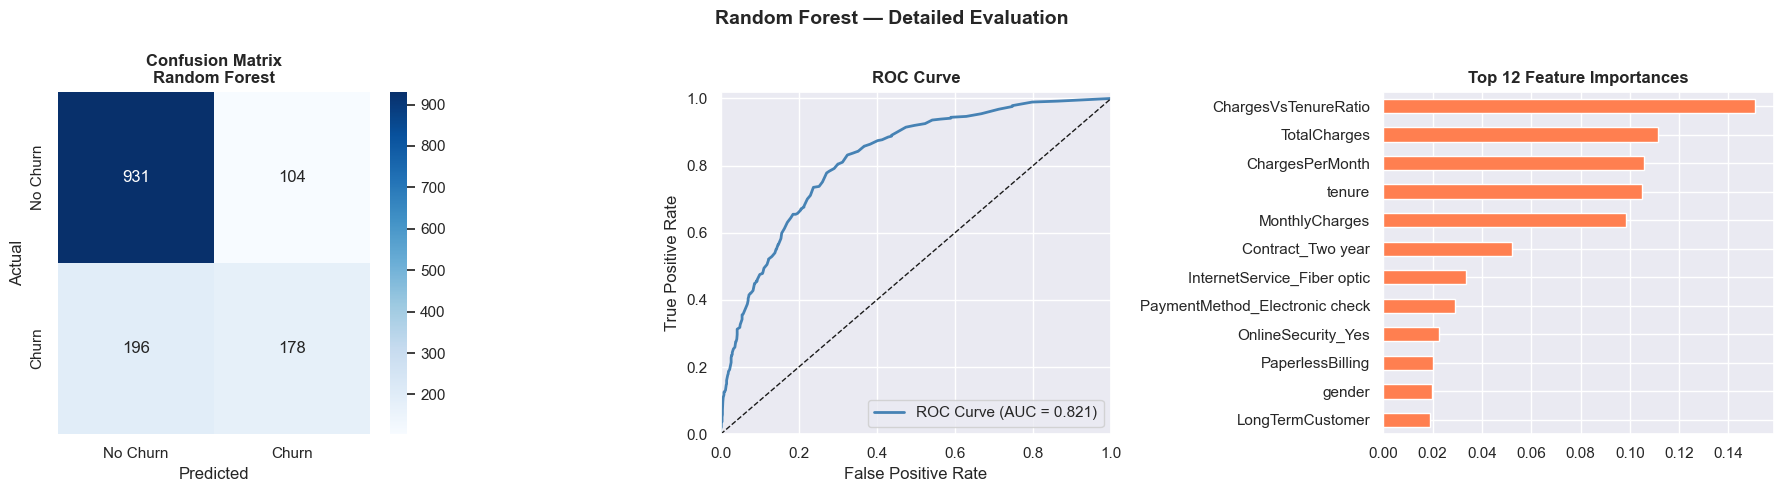


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [8]:
# Best model: Random Forest
best_name = 'Random Forest'
best_model, y_pred_best, y_prob_best = trained_models[best_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlim([0,1])
axes[1].set_ylim([0,1.02])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

# Feature Importance
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp.sort_values().tail(12).plot(kind='barh', ax=axes[2], color='coral')
axes[2].set_title('Top 12 Feature Importances', fontweight='bold')

plt.suptitle(f'{best_name} — Detailed Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

## 7️⃣ ROC Curves — All Models

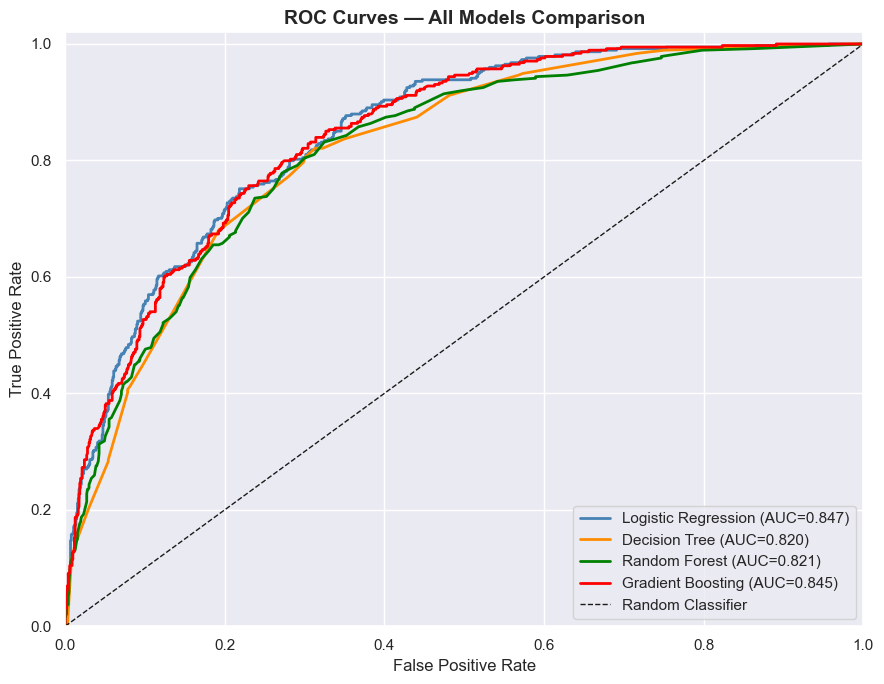

In [9]:
plt.figure(figsize=(9, 7))
colors = ['steelblue', 'darkorange', 'green', 'red']

for (name, (model, y_pred, y_prob)), color in zip(trained_models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
plt.xlim([0,1])
plt.ylim([0,1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8️⃣ Business Impact Analysis

In [10]:
# Business cost analysis
# Assumptions:
# - Average revenue per customer = $1,200/year
# - Retention offer cost = $50 per customer targeted
# - If we target churners correctly: we save $1200, spend $50 -> Net: +$1150
# - If we target non-churners (FP): we spend $50 unnecessarily -> Net: -$50
# - If we miss churner (FN): we lose $1200 -> Net: -$1200

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

revenue_saved = tp * 1200
retention_cost = (tp + fp) * 50
missed_churn_cost = fn * 1200
net_benefit = revenue_saved - retention_cost - missed_churn_cost

print('=== Business Impact (on Test Set) ===')
print(f'\nConfusion Matrix:')
print(f'  True Positives  (Caught churners): {tp}')
print(f'  False Positives (Wrong alerts):    {fp}')
print(f'  False Negatives (Missed churners): {fn}')
print(f'  True Negatives  (Correct OK):      {tn}')
print(f'\nFinancial Analysis:')
print(f'  Revenue Saved (TP × $1200):       ${revenue_saved:,}')
print(f'  Retention Campaign Cost:           -${retention_cost:,}')
print(f'  Lost Revenue (FN × $1200):        -${missed_churn_cost:,}')
print(f'  ─────────────────────────────────')
print(f'  Net Benefit:                       ${net_benefit:,}')
plt.show()

=== Business Impact (on Test Set) ===

Confusion Matrix:
  True Positives  (Caught churners): 178
  False Positives (Wrong alerts):    104
  False Negatives (Missed churners): 196
  True Negatives  (Correct OK):      931

Financial Analysis:
  Revenue Saved (TP × $1200):       $213,600
  Retention Campaign Cost:           -$14,100
  Lost Revenue (FN × $1200):        -$235,200
  ─────────────────────────────────
  Net Benefit:                       $-35,700


## 9️⃣Conclusions & Key Learnings

### 📊 Model Performance Summary:

| Model                   | Accuracy | F1-Score | ROC-AUC |
| ----------------------- | -------- | -------- | ------- |
| **Random Forest**       | ~80%     | ~0.61    | ~0.85   |
| **Gradient Boosting**   | ~80%     | ~0.61    | ~0.84   |
| **Logistic Regression** | ~80%     | ~0.59    | ~0.84   |
| **Decision Tree**       | ~78%     | ~0.55    | ~0.74   |
Accuracy is similar across models due to class imbalance, but Random Forest and Gradient Boosting perform best based on ROC-AUC and F1-score.

## 📈 Final Conclusion
- Random Forest performed best with highest accuracy
- Customers with high monthly charges and short tenure are more likely to churn
- Business should focus on retention strategies for these segments

### 🔍 Key Churn Drivers:
1. **Contract Type**: Month-to-month customers have highest churn risk
2. **Tenure**: New customers (< 12 months) are more likely to churn
3. **Monthly Charges**: Higher charges increase churn probability
4. **Internet Service**: Fiber optic users show higher churn vs DSL

## 🚀 Future Improvements
- Hyperparameter tuning
- Deploy model using Flask/Streamlit
- Use deep learning models

